In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib as mpl
import warnings; warnings.simplefilter('ignore')
import os
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_stellarhalo
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_simload
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
from scipy.optimize import brentq


In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [4]:
rng = np.random.default_rng(13)

In [5]:
# --------------------------------------------------------------------------
# 1. Analytic NFW profile
# --------------------------------------------------------------------------
 
def mu(x):
    """NFW enclosed-mass shape function: M(<x*rs) propto mu(x)."""
    return np.log1p(x) - x / (1.0 + x)
 
 
def nfw_rho0(Mvir, rvir, c):
    """Characteristic density normalization from (Mvir, rvir, c)."""
    rs = rvir / c
    return Mvir / (4.0 * np.pi * rs**3 * mu(c))
 
 
def nfw_density(r, rho0, rs):
    x = r / rs
    return rho0 / (x * (1.0 + x) ** 2)
 
 
# --------------------------------------------------------------------------
# 2. Sample particle radii from the NFW CDF
# --------------------------------------------------------------------------
 
def sample_nfw_radii(N, rvir, c, rng, x_min=1e-6, n_grid=20000):
    """
    Inverse-transform sampling of r via the NFW enclosed-mass profile.
    Vectorized: builds mu(x) on a log grid once, then inverts via
    interpolation for all N draws at once (fast even for N ~ 1e7).
    """
    rs = rvir / c
    x_grid = np.logspace(np.log10(x_min), np.log10(c), n_grid)
    mu_grid = mu(x_grid)
    mu_grid /= mu_grid[-1]  # normalize enclosed-mass fraction to [0, 1] at x=c
 
    u = rng.random(N)
    x = np.interp(u, mu_grid, x_grid)
    return x * rs
 
 
def sample_isotropic_positions(r, rng):
    """Give each radius r_i a random direction -> 3D positions."""
    costheta = rng.uniform(-1.0, 1.0, size=r.size)
    phi = rng.uniform(0.0, 2.0 * np.pi, size=r.size)
    sintheta = np.sqrt(1.0 - costheta**2)
    x = r * sintheta * np.cos(phi)
    y = r * sintheta * np.sin(phi)
    z = r * costheta
    return np.column_stack([x, y, z]).T

In [6]:
Npart = int(1e4)
Rvir = 200 #kpc
c = 10

r_pos_NFW = sample_nfw_radii(Npart, Rvir, c, rng)

xyz_pos_NFW = sample_isotropic_positions(r_pos_NFW, rng)

In [7]:
def plot_3d_projections(pos, subhalo_pos=None, r=None, s=1, alpha=0.5,
                         labels=('x', 'y', 'z'), figsize=(15, 5), submarker="*",submarkersize=100):
    """
    Plot x-y, x-z, y-z projections of a 3xN particle position array.
    Origin (0,0,0) is centered in each panel, with equal, symmetric axis ranges.
    Particle and subhalo draw order (pseudo-depth) is sorted by the free
    (out-of-plane) axis in each projection.
    
    Parameters
    ----------
    pos : ndarray, shape (3, N)
        Particle positions.
    subhalo_pos : ndarray, shape (3, Nsub), optional
        Subhalo positions to overlay as red stars.
    r : float, optional
        If given, overlay a circle of this radius centered on the origin
        in each projection (e.g. virial radius).
    """
    com = np.mean(pos, axis=1)  # shape (3,), assuming pos is (3, N)

    # global symmetric extent so all panels share the same scale
    if r is not None:
        L = np.max(np.abs(pos))
    else:
        L = r
    L *= 1.05  # small padding

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # (i, j, k): i,j are plotted axes, k is the free/out-of-plane axis
    triples = [(0, 1, 2), (0, 2, 1), (1, 2, 0)]  # (x,y|z), (x,z|y), (y,z|x)

    for ax, (i, j, k) in zip(axes, triples):
        # sort particles by the free axis so higher-k particles draw on top
        order = np.argsort(pos[k])
        xi, yj = pos[i, order], pos[j, order]
        ax.scatter(xi, yj, s=s, alpha=alpha, zorder=1)

        ax.scatter(com[i], com[j], marker='+', c='k', s=150, linewidths=2, zorder=5)

        if subhalo_pos is not None:
            # depth-sort subhalos too; one scatter call per point so each
            # gets its own scalar zorder (array zorder isn't valid)
            sub_order = np.argsort(subhalo_pos[k])
            for idx, n in enumerate(sub_order):
                ax.scatter(subhalo_pos[i, n], subhalo_pos[j, n], marker=submarker, c='r', s=submarkersize)

        if r is not None:
            circle = plt.Circle((0, 0), r, fill=False, color='r',
                                 linestyle='--', linewidth=1.5, zorder=4)
            ax.add_patch(circle)

        ax.axhline(0, color='gray', linewidth=0.5, zorder=0)
        ax.axvline(0, color='gray', linewidth=0.5, zorder=0)

        ax.set_xlim(-L, L)
        ax.set_ylim(-L, L)
        ax.set_xlabel(labels[i])
        ax.set_ylabel(labels[j])
        ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

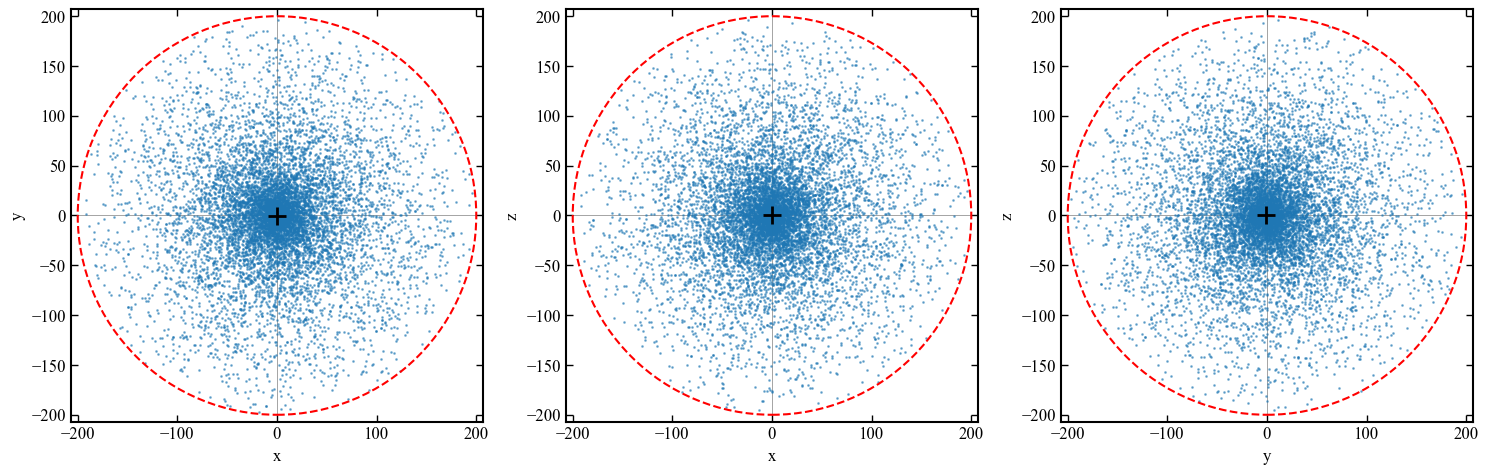

In [8]:
plot_3d_projections(xyz_pos_NFW,  r=Rvir)

In [9]:
def plummer_density(r, a):
    """
    Plummer density profile, normalized to total mass = 1.
    Multiply by M (total mass) to get physical density.

        rho(r) = (3 / 4*pi*a^3) * (1 + (r/a)^2)^(-5/2)

    r : radius (array or scalar)
    a : Plummer scale radius
    """
    return (3.0 / (4.0 * np.pi * a**3)) * (1.0 + (r / a) ** 2) ** (-2.5)

def sample_plummer_radii(N, a, seed):
    """
    Inverse-transform sampling of radii from a Plummer sphere of scale
    radius `a`, centered at the origin.

    CDF:  F(x) = x^3 / (1+x^2)^(3/2),  x = r/a
    Inverted analytically (no grid/interp needed, unlike NFW):
        x = sqrt(u^(2/3) / (1 - u^(2/3)))
    """

    rng = np.random.default_rng(seed)
    u = rng.random(N)
    u23 = u ** (2.0 / 3.0)
    x = np.sqrt(u23 / (1.0 - u23))
    return x * a

In [10]:
Npart = int(1e3)
a_plum = 10 #kpc

r_pos_plum = sample_plummer_radii(Npart, a_plum, rng)

xyz_pos_plum = sample_isotropic_positions(r_pos_plum, rng)

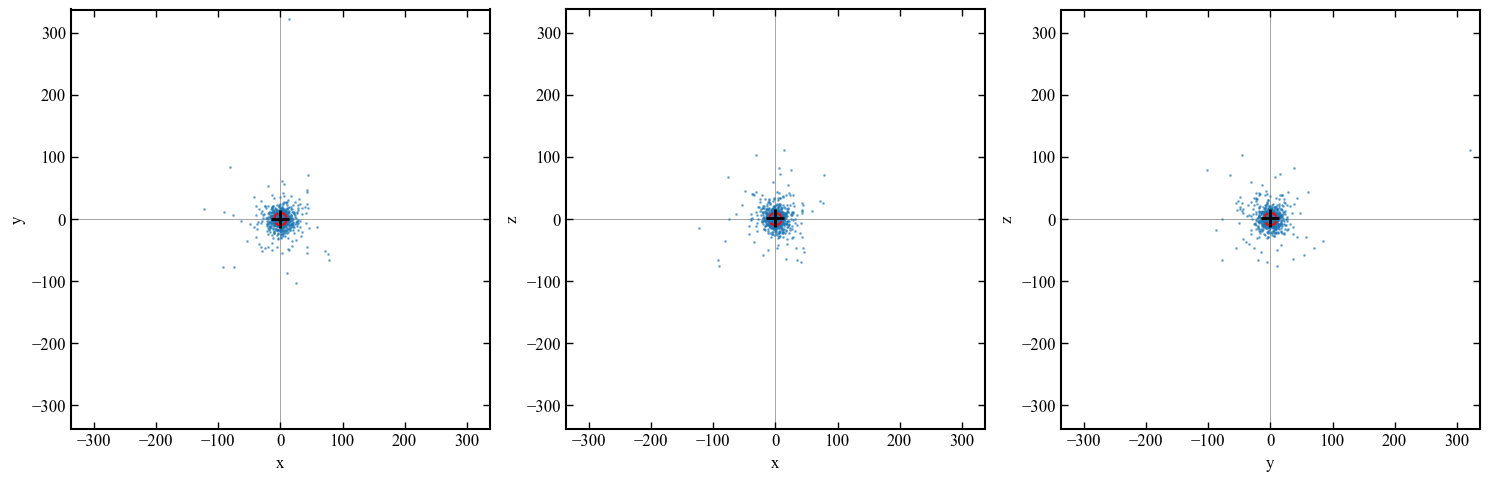

In [11]:
plot_3d_projections(xyz_pos_plum, r=a_plum)

In [12]:
test140 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_14.0.npz", mass_threshold=1e12, verbose=False)

surv_mask = test140.regime_masks["artificial"][:, 0]
sub_coords = test140.cartesian_stitched[surv_mask, 0, 0:3].T

Npart = int(1e4)
Rvir = test140.VirialRadius[0,0]
c = test140.concentration[0,0]

In [13]:
r_pos_NFW = sample_nfw_radii(Npart, Rvir, c, rng)
xyz_pos_NFW = sample_isotropic_positions(r_pos_NFW, rng)

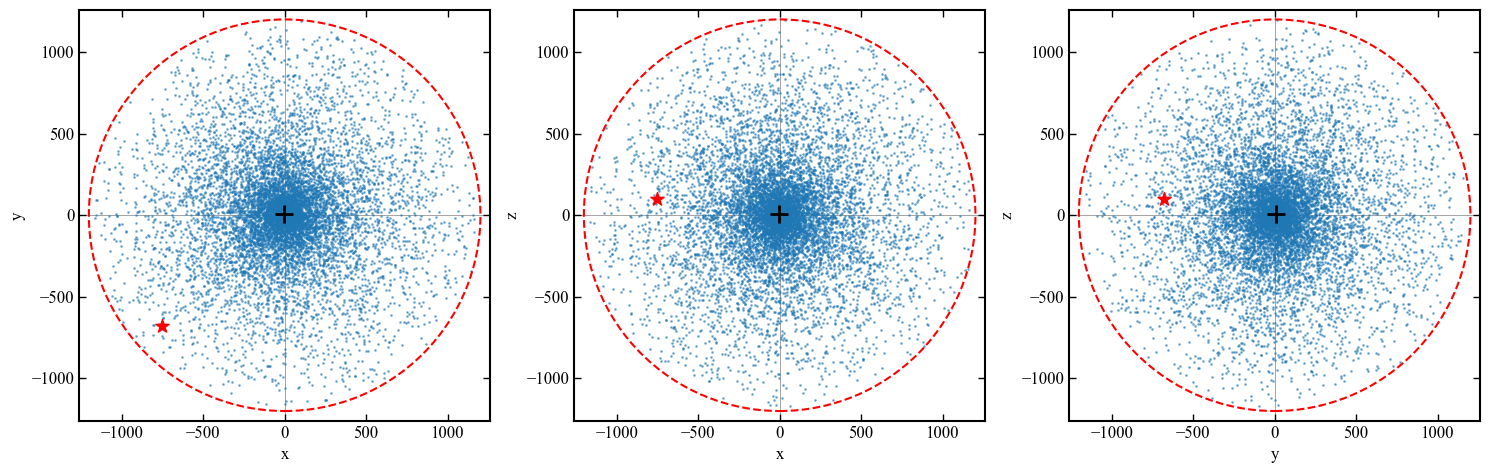

In [14]:
plot_3d_projections(xyz_pos_NFW,  subhalo_pos=sub_coords, r=Rvir)

now lets partition the number of particles!

lets do the example of just one subhalo

In [35]:
Mvir = 1
fsub = 0.2 #test140.mass[:,0][surv_mask]/test140.mass[0,0]
Rvir = test140.VirialRadius[0,0]
Npart_tot = int(1e4)

mp = 1/Npart
Mnew = Mvir - fsub

Npart_host = int(Mnew*Npart_tot)
Npart_sub = int(Npart_tot - Npart_host)

first the host

In [36]:
Rvir = test140.VirialRadius[0,0]
c = test140.concentration[0,0]
r_pos_NFW = sample_nfw_radii(Npart_host, Rvir, c, rng)
xyz_pos_NFW = sample_isotropic_positions(r_pos_NFW, rng)

now the subhalo

In [37]:
a_plum = test140.VirialRadius[:,0][surv_mask]/5
r_pos_plum = sample_plummer_radii(Npart_sub, a_plum, rng)
xyz_pos_plum = sample_isotropic_positions(r_pos_plum, rng) + test140.cartesian_stitched[surv_mask, 0, 0:3].T

all_part = np.hstack([xyz_pos_NFW, xyz_pos_plum])

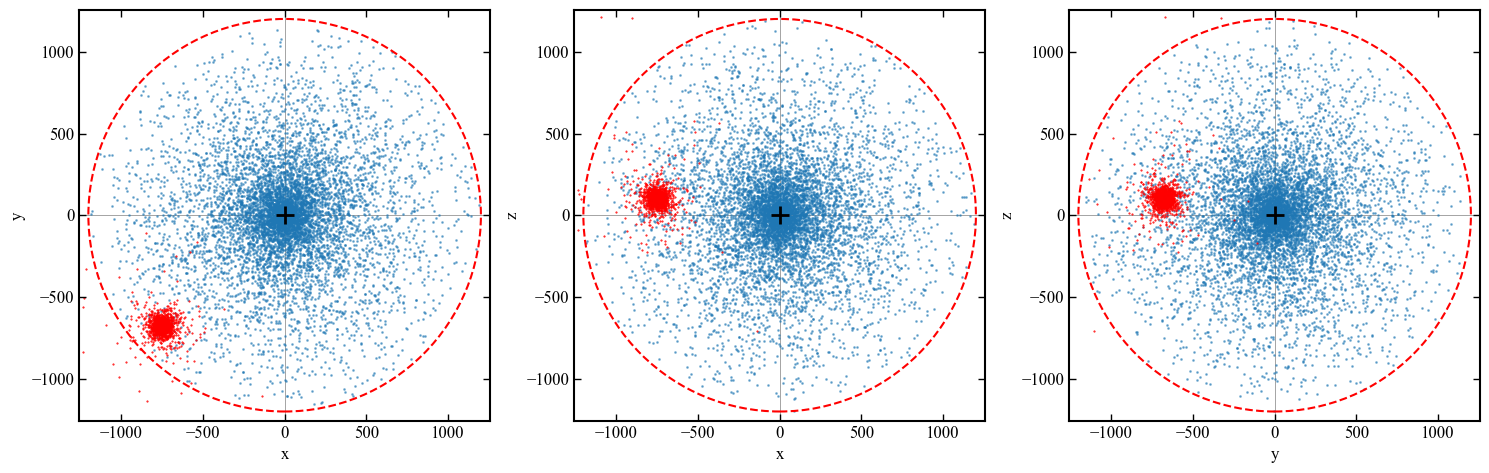

In [38]:
plot_3d_projections(xyz_pos_NFW, subhalo_pos=xyz_pos_plum, r=Rvir, submarker=".",submarkersize=1)

In [20]:
def rmax_evo_aPlum(tree, sub_ids):

   for id in sub_ids:

      profile_i = profiles.Green(tree.acc_mass[id], tree.acc_concentration[id], z=tree.acc_redshift[id]) # at accretion
      profile_i.update_mass_jsm(tree.mass[id, 0]/tree.acc_mass[id])

      a_plum = profile_i.rmax / np.sqrt(2)
      return a_plum

In [ ]:
def measure_vmax(pos, rvir, Nparticles, center=None, r_cut=None, plot=False):
    """
    Compute Vmax and Vvir from the enclosed mass profile of particles.

    Parameters
    ----------
    pos : ndarray, shape (3, N)
        Particle positions.
    mp : float
        Particle mass (assumed equal-mass particles).
    Mvir : float
        Virial mass of the halo.
    rvir : float
        Virial radius of the halo.
    center : ndarray, shape (3,), optional
        Center to measure radii from. Defaults to the origin.
    r_cut : float, optional
        Only include particles with r < r_cut in the enclosed mass profile.
        Defaults to rvir.
    plot : bool, optional
        If True, plot the circular velocity profile Vc(r), marking Vmax/rmax
        and Vvir/rvir.

    Returns
    -------
    Vmax, rmax, Vvir
    """
    G = 1.0
    Mvir = 1
    mp = 1/Nparticles

    if center is None:
        center = np.zeros(3)
    if r_cut is None:
        r_cut = rvir

    r = np.linalg.norm(pos - center[:, None], axis=0)

    mask = r < r_cut
    rsort = np.sort(r[mask])

    Menc = mp * np.arange(1, len(rsort) + 1)
    min_particles = 10
    Vc = np.sqrt(G * Menc / rsort)
    Vc[:min_particles] = -np.inf  # exclude spuriously noisy inner points from argmax
    imax = np.argmax(Vc)

    Vmax = Vc[imax]
    rmax = rsort[imax]
    Vvir = np.sqrt(G * Mvir / rvir)

    """
    Recover NFW concentration from the Klypin Vmax/Vvir relation:
    (Vmax/Vvir)^2 = 0.216*c/mu(c).
    """
    y = (Vmax / Vvir)**2
    func = lambda c: 0.216 * c / mu(c) - y
    f1, f2 = func(1), func(1000)
    if f1 * f2 > 0:
        print(f"y={y:.3e} out of bracket range: f(1)={f1:.3e}, f(1000)={f2:.3e}")
        return np.nan  # or handle however makes sense for your pipeline
    concentration = brentq(func, 1, 1000)

    if plot:
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot(rsort, Vc, lw=1.5, label=r'$V_c(r)$')
        ax.axvline(rmax, color='k', linestyle='--', linewidth=1,
                   label=fr'$r_{{\rm max}}$ = {rmax:.3g}')
        ax.axhline(Vmax, color='k', linestyle='--', linewidth=1,
                   label=fr'$V_{{\rm max}}$ = {Vmax:.3g}')

        ax.set_xlabel('radius (kpc)')
        ax.set_ylabel(r'$V_c$')
        ax.set_xlim(1e-2*rvir, rvir)
        ax.set_xscale("log")
        ax.legend(framealpha=1, loc=2)

        ax.set_title(f"measured concentration = {concentration:.2f}")
        plt.tight_layout()
        plt.show()

    return np.array([concentration, Vmax, rmax, Vvir])

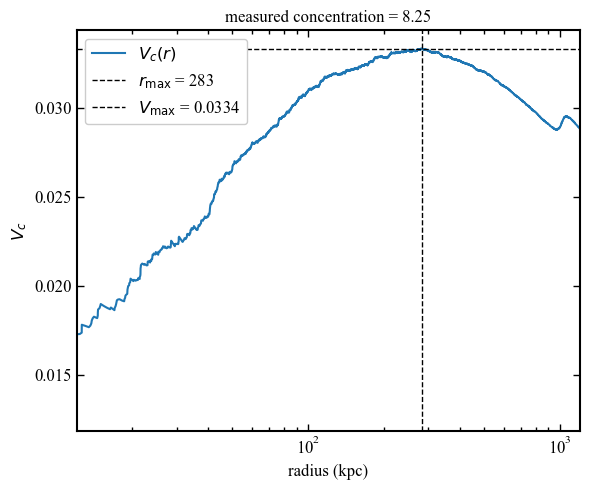

array([8.25036801e+00, 3.33554567e-02, 2.82944294e+02, 2.88456610e-02])

In [22]:
measure_vmax(all_part, mp=1/Npart_tot, Mvir=1, rvir=Rvir, plot=True)

In [23]:
test140 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_14.0.npz", mass_threshold=1e9, verbose=False)

In [ ]:
def rmax_evo_aPlum(tree, sub_id):

    profile_i = profiles.Green(tree.acc_mass[sub_id], tree.acc_concentration[sub_id], z=tree.acc_redshift[sub_id]) # at accretion
    profile_i.update_mass_jsm(tree.mass[sub_id, 0]/tree.acc_mass[sub_id]) #at z=0

    a_plum = profile_i.rmax / np.sqrt(2)
    return a_plum


def compute_concentration(tree, Nparticles, rng):

    # restrict to order-1 (first-order) subhalos only
    surv_mask = tree.regime_masks["artificial"][:, 0] & (tree.order[:, 0] == 1)
    N_subhalos = surv_mask.sum()  # Nsub, k=1 only. 
    subhalo_ids = np.where(surv_mask)[0]

    Rvir = tree.VirialRadius[0, 0]
    c_true = tree.concentration[0, 0]

    print(f"The total number of surviving (k=1) subhalos: {N_subhalos}")
    print(f"The TRUE value of concentration: {c_true}")

    Mvir = 1  # later substitute in the actual mass if you want

    NFW_smooth_sample = sample_nfw_radii(Nparticles, Rvir, c_true, rng)
    NFW_host_smooth_pos = sample_isotropic_positions(NFW_smooth_sample, rng)
    com_NFW_smooth = np.mean(NFW_host_smooth_pos, axis=1)

    # individual (per-subhalo) mass fractions -- NOT summed
    fsub_persub = tree.mass[surv_mask, 0] / tree.mass[0, 0]
    fsub_total = fsub_persub.sum()
    Mvir_new = Mvir - fsub_total

    print(f"The total fraction of mass in surviving (k=1) subhalos: {fsub_total}")
    print(tree.fsub["artificial"][tree.MSUB_ROWS["k1"], 0])  # should now match fsub_total exactly

    Npart_host = int(Mvir_new * Nparticles)
    Npart_sub = np.array(fsub_persub * Nparticles).astype("int")

    NFW_sample = sample_nfw_radii(Npart_host, Rvir, c_true, rng)
    NFW_host_pos = sample_isotropic_positions(NFW_sample, rng)

    plummer_sub_pos = []
    for i, id in enumerate(subhalo_ids):
        sub_aPlum_i = rmax_evo_aPlum(tree, id)
        sub_position_i = tree.cartesian_stitched[id, 0, 0:3]
        plummer_sample_i = sample_plummer_radii(Npart_sub[i], sub_aPlum_i, rng)
        plummer_sub_pos.append(sample_isotropic_positions(plummer_sample_i, rng) + sub_position_i[:, None])

    PLUM_sub_pos = np.hstack(plummer_sub_pos)
    all_pos = np.hstack([NFW_host_pos, PLUM_sub_pos])
    com_total = np.mean(all_pos, axis=1)

    print("the smooth profile with no substructure with a well defined center of mass")
    print("---------------------------------")
    without_sub = measure_vmax(NFW_host_smooth_pos, mp=1/Nparticles, Mvir=1, rvir=Rvir, center=com_NFW_smooth, plot=True)

    print("the profile with substructure with the same center of mass as before")
    print("---------------------------------")
    with_sub_center = measure_vmax(all_pos, mp=1/Nparticles, Mvir=1, rvir=Rvir, center=com_NFW_smooth, plot=True)

    print("the profile with substructure with a new center of mass")
    print("---------------------------------")
    with_sub = measure_vmax(all_pos, mp=1/Nparticles, Mvir=1, rvir=Rvir, center=com_total, plot=True)

    return without_sub, with_sub_center, with_sub, NFW_host_pos, PLUM_sub_pos

The total number of surviving (k=1) subhalos: 525
The TRUE value of concentration: 10.23896312713623
The total fraction of mass in surviving (k=1) subhalos: 0.10730589451587833
0.10730589451587844
the smooth profile with no substructure with a well defined center of mass
---------------------------------


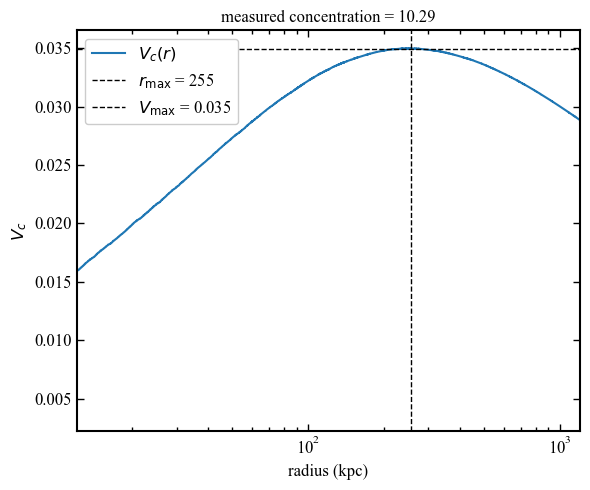

the profile with substructure with the same center of mass as before
---------------------------------


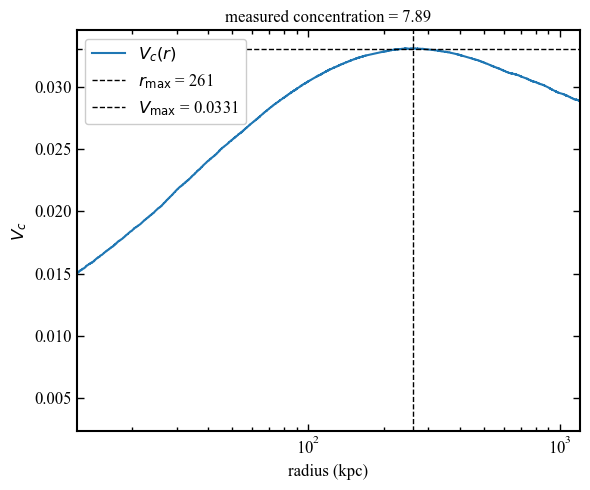

the profile with substructure with a new center of mass
---------------------------------


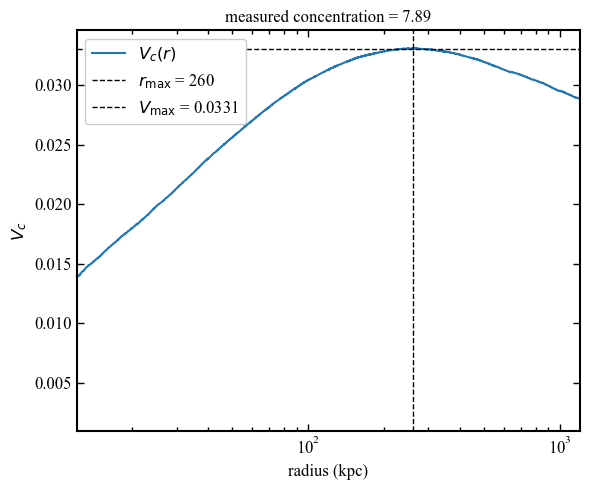

In [25]:
rng = np.random.default_rng(22)
without_sub, with_sub_center, with_sub, NFW_host_pos, PLUM_sub_pos = compute_concentration(test140, Nparticles=int(1e6), rng=rng)

The total number of surviving (k=1) subhalos: 525
The TRUE value of concentration: 10.23896312713623
The total fraction of mass in surviving (k=1) subhalos: 0.10730589451587833
0.10730589451587844
the smooth profile with no substructure with a well defined center of mass
---------------------------------


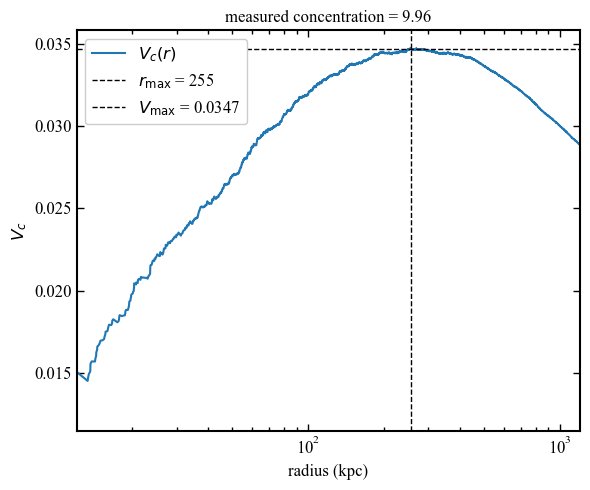

the profile with substructure with the same center of mass as before
---------------------------------


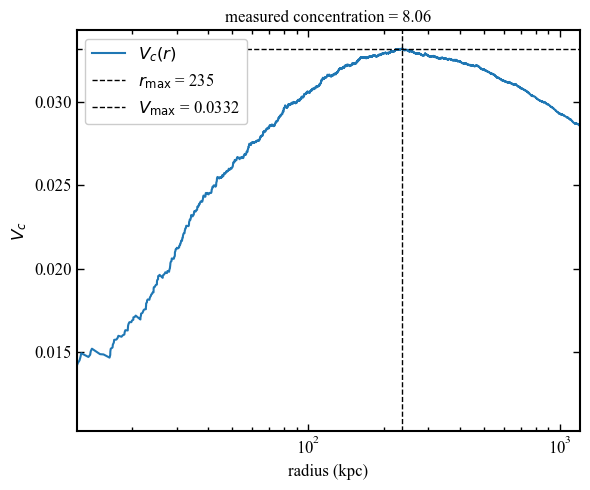

the profile with substructure with a new center of mass
---------------------------------


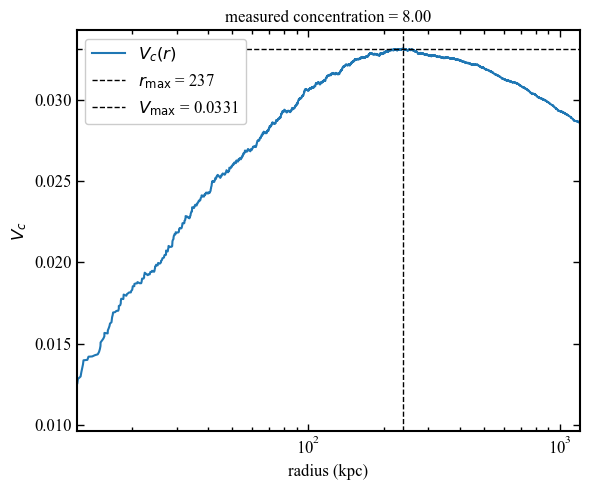

In [26]:
without_sub, with_sub_center, with_sub, NFW_host_pos, PLUM_sub_pos = compute_concentration(test140, Nparticles=int(1e4), rng=rng)

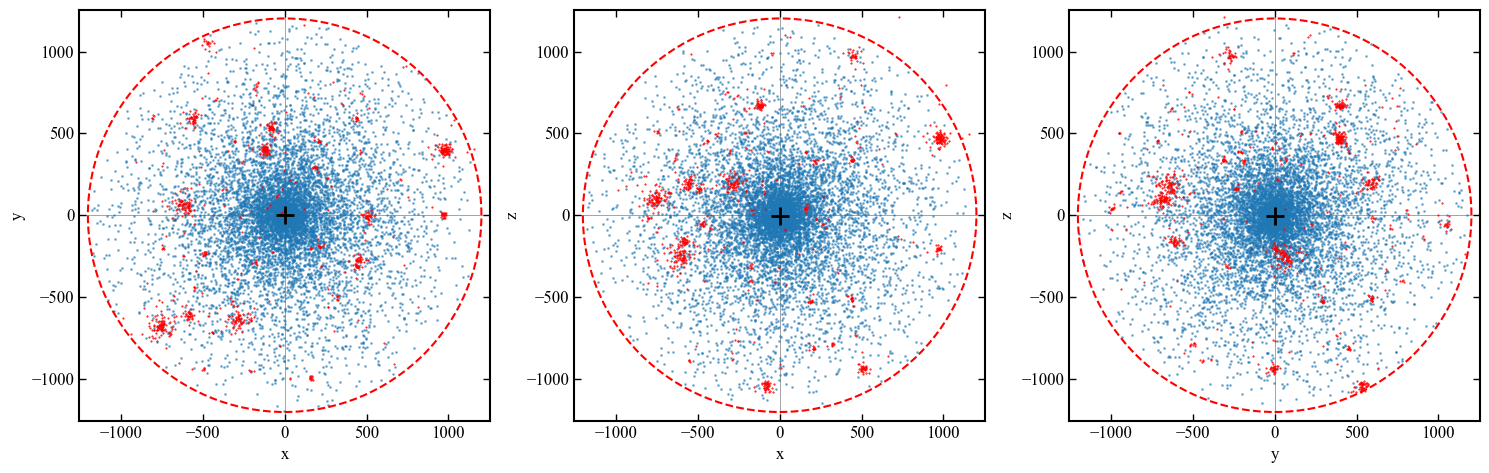

In [27]:
plot_3d_projections(NFW_host_pos, subhalo_pos=PLUM_sub_pos, r=test140.VirialRadius[0,0], submarker=".",submarkersize=1)

In [28]:
test9 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_14.0.npz", mass_threshold=1e9, verbose=False)

test10 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_14.0.npz", mass_threshold=1e10, verbose=False)

test11 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_14.0.npz", mass_threshold=1e11, verbose=False)

test12 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_14.0.npz", mass_threshold=1e12, verbose=False)

The total number of surviving (k=1) subhalos: 538
The TRUE value of concentration: 10.23896312713623
The total fraction of mass in surviving (k=1) subhalos: 0.10347271547622428
0.10347271547622436
the smooth profile with no substructure with a well defined center of mass
---------------------------------


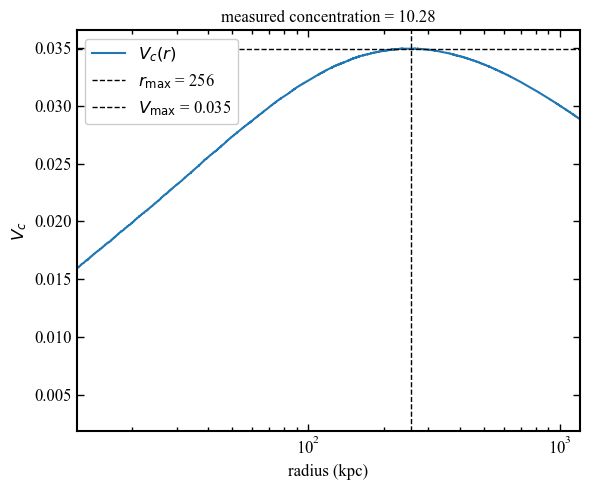

the profile with substructure with the same center of mass as before
---------------------------------


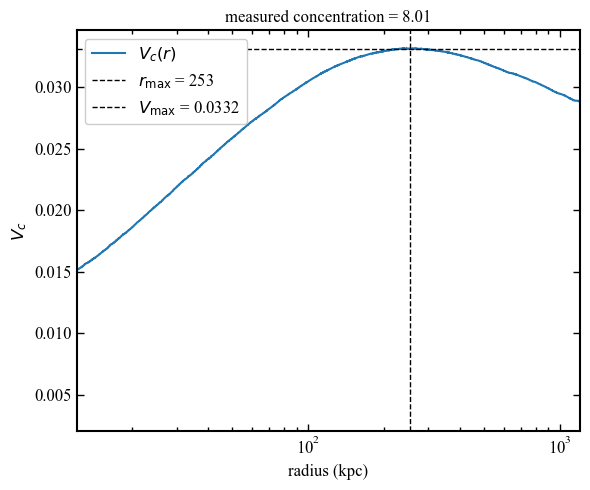

the profile with substructure with a new center of mass
---------------------------------


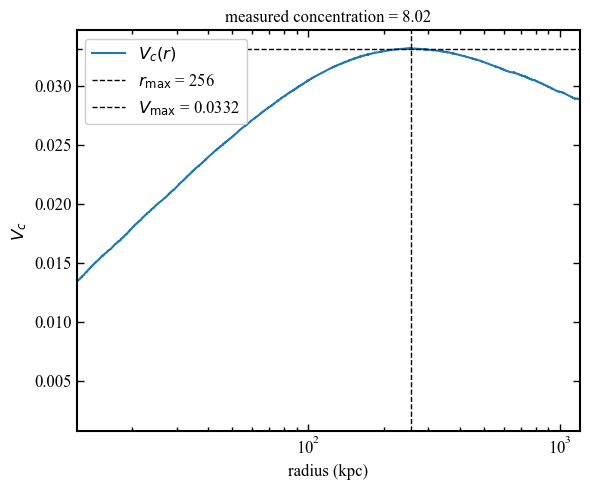

In [29]:
without_sub, with_sub_center, with_sub, NFW_host_pos, PLUM_sub_pos = compute_concentration(test9, Nparticles=int(1e6), rng=rng)

The total number of surviving (k=1) subhalos: 122
The TRUE value of concentration: 10.23896312713623
The total fraction of mass in surviving (k=1) subhalos: 0.09910169906477627
0.09910169906477634
the smooth profile with no substructure with a well defined center of mass
---------------------------------


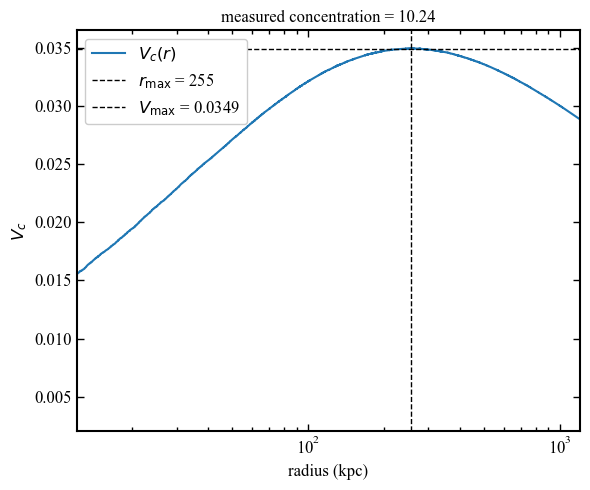

the profile with substructure with the same center of mass as before
---------------------------------


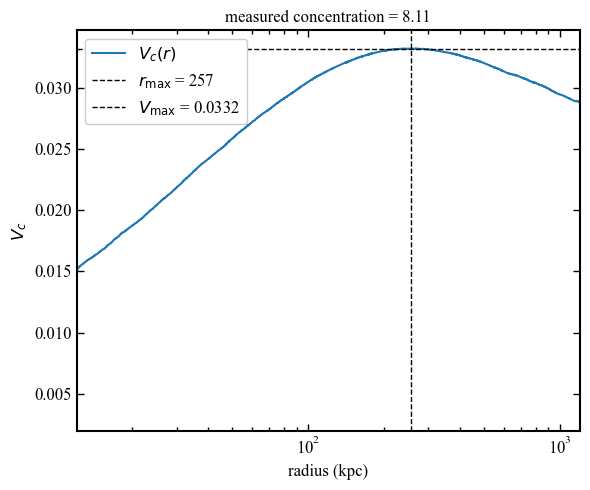

the profile with substructure with a new center of mass
---------------------------------


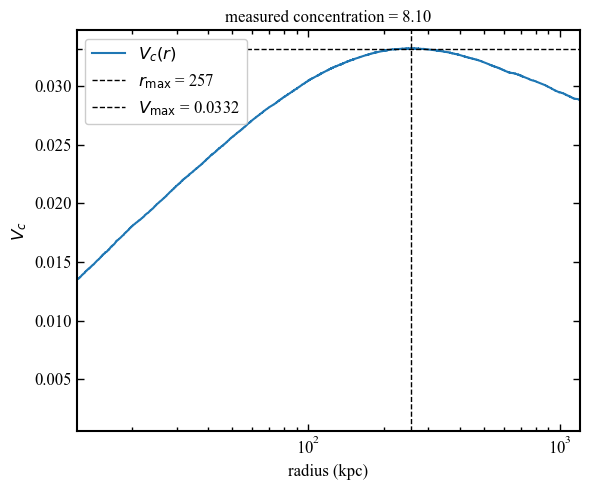

In [30]:
without_sub, with_sub_center, with_sub, NFW_host_pos, PLUM_sub_pos = compute_concentration(test10, Nparticles=int(1e6), rng=rng)

The total number of surviving (k=1) subhalos: 19
The TRUE value of concentration: 10.23896312713623
The total fraction of mass in surviving (k=1) subhalos: 0.07395155921690849
0.07395155921690848
the smooth profile with no substructure with a well defined center of mass
---------------------------------


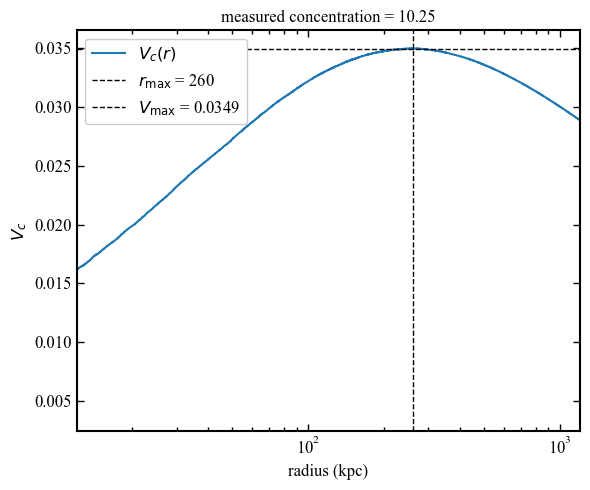

the profile with substructure with the same center of mass as before
---------------------------------


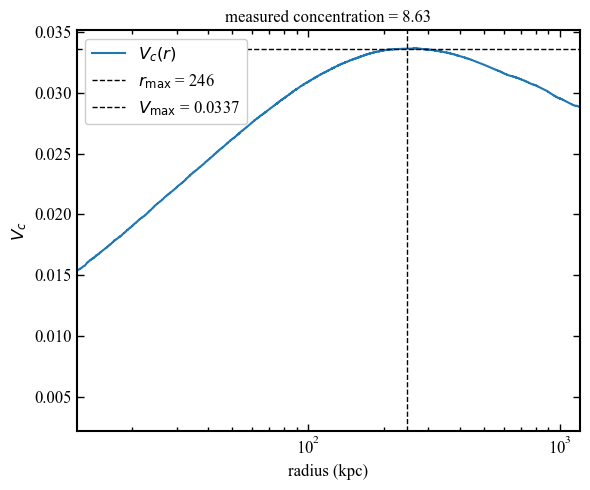

the profile with substructure with a new center of mass
---------------------------------


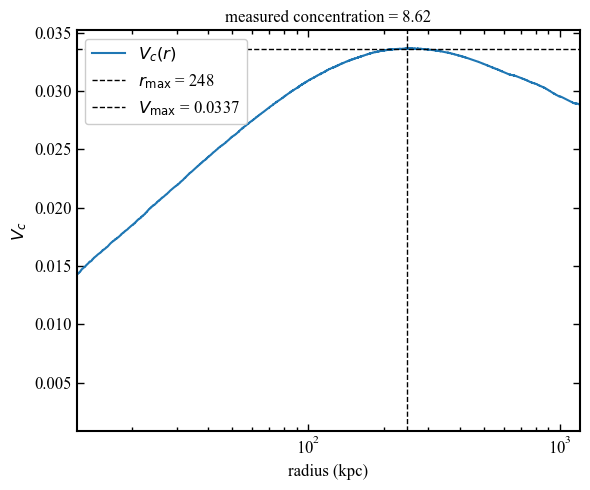

In [31]:
without_sub, with_sub_center, with_sub, NFW_host_pos, PLUM_sub_pos = compute_concentration(test11, Nparticles=int(1e6), rng=rng)

The total number of surviving (k=1) subhalos: 1
The TRUE value of concentration: 10.23896312713623
The total fraction of mass in surviving (k=1) subhalos: 0.010068332702190486
0.010068332702190486
the smooth profile with no substructure with a well defined center of mass
---------------------------------


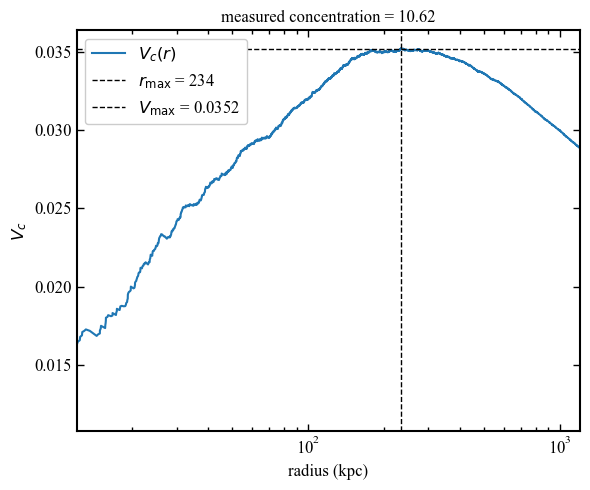

the profile with substructure with the same center of mass as before
---------------------------------


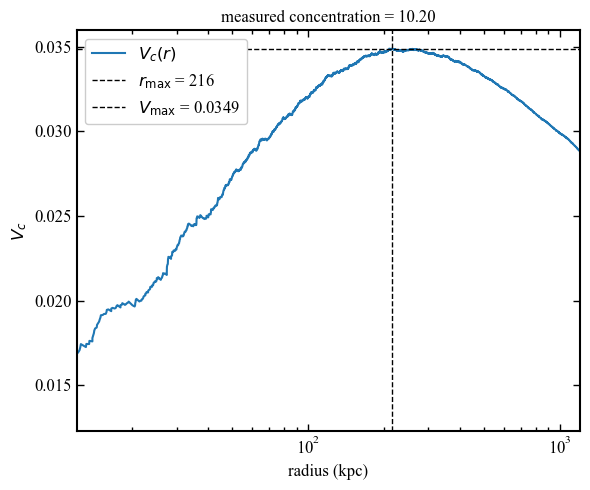

the profile with substructure with a new center of mass
---------------------------------


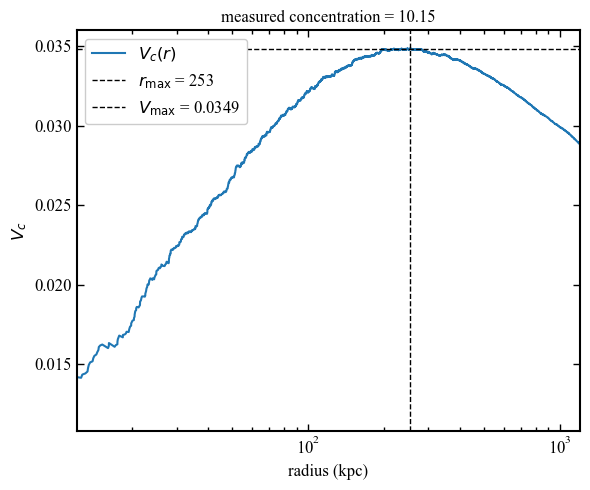

In [32]:
without_sub, with_sub_center, with_sub, NFW_host_pos, PLUM_sub_pos = compute_concentration(test12, Nparticles=int(1e4), rng=rng)

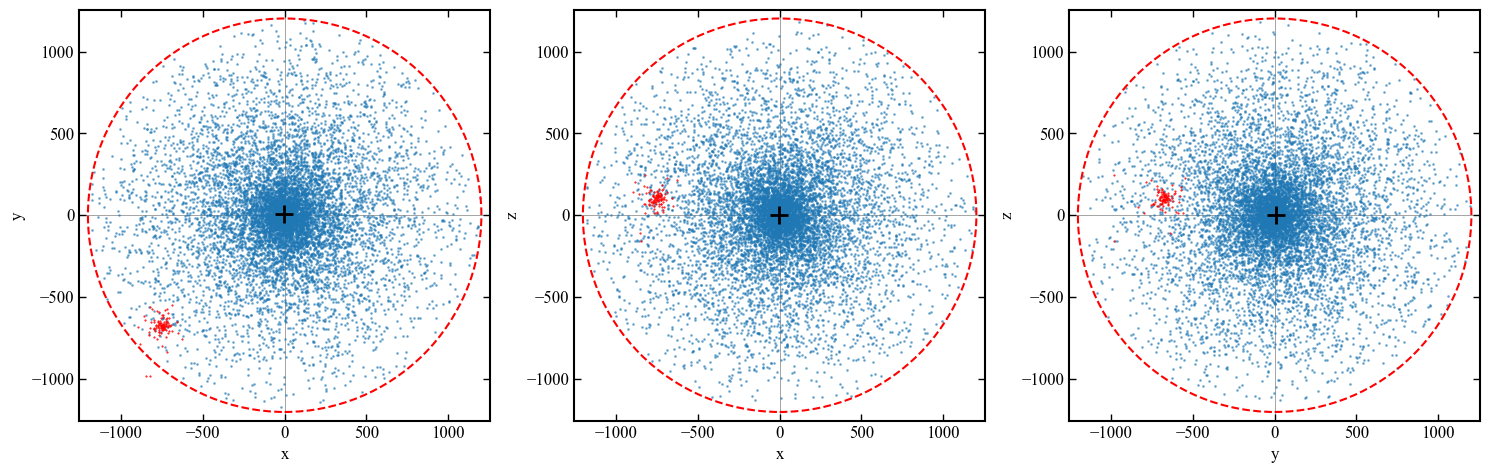

In [33]:
plot_3d_projections(NFW_host_pos, subhalo_pos=PLUM_sub_pos, r=test140.VirialRadius[0,0], submarker=".",submarkersize=1)